## IMPORT THE DATA AND NECESSARY LIBRARIES.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
merged_data = pd.read_excel('./merged_data.xlsx')

# STATISTICAL ANALYSIS

## 1. Univariate Analysis

The goal here is to understand the distribution, variation, and frequency of each variable.

### 1.1 Categorical Variaables.

/tmp/ipython-input-2467458455.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=column, data=merged_data, palette='viridis')


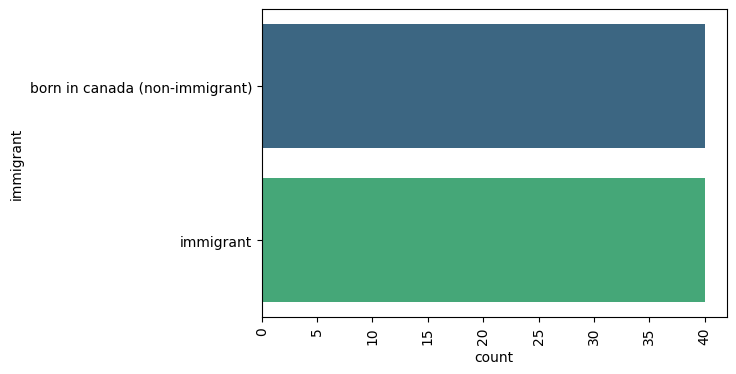

/tmp/ipython-input-2467458455.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=column, data=merged_data, palette='viridis')


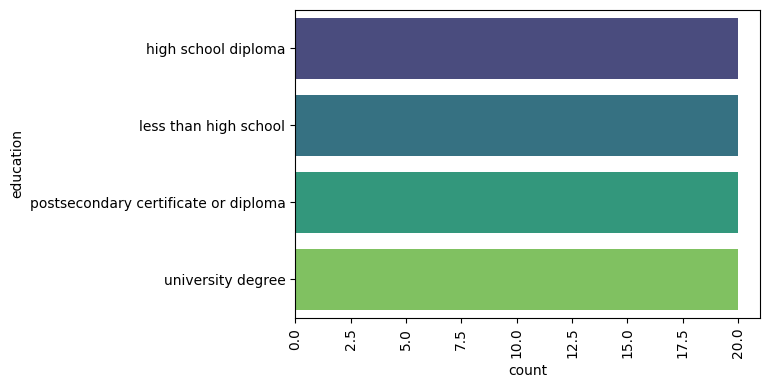

/tmp/ipython-input-2467458455.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=column, data=merged_data, palette='viridis')


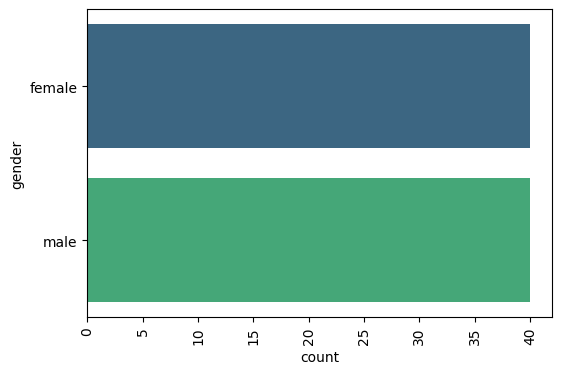

In [ ]:
categorical_columns = merged_data.select_dtypes(include=['object']).columns
for column in categorical_columns:
    plt.figure(figsize= (6, 4))
    sns.countplot(y=column, data=merged_data, palette='viridis')
    plt.xticks(rotation=90)
    plt.show()

**Observation:** From the charts, the dataset has a balanced number of records for each category. This means the number of males and females, immigrants and non-immigrants, and all education levels are almost equal.

This happened because the data was created using pivot tables, where every combination of Year, Education Level, Gender, and Immigration Status was included once.

### 1.2 Numerical Variables.

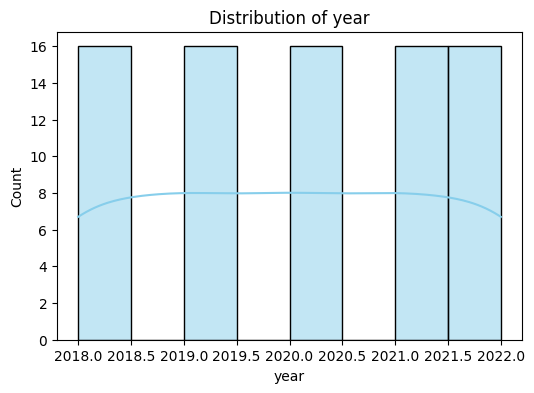

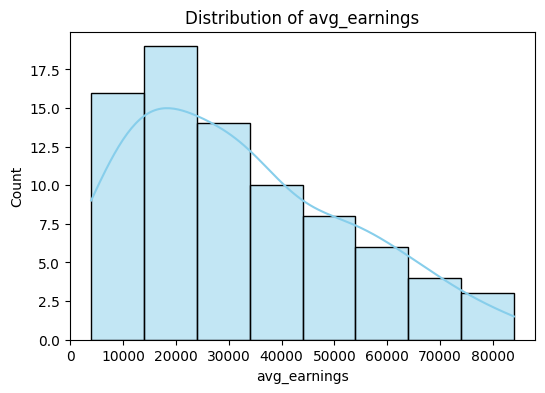

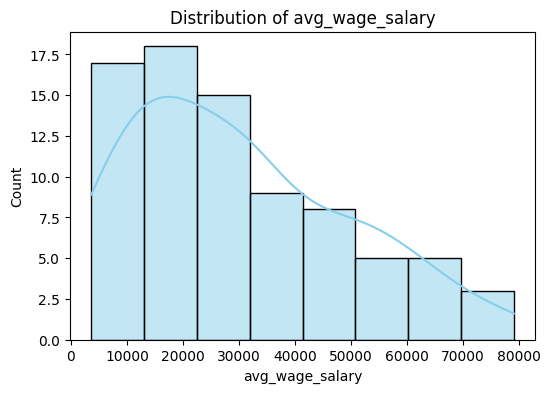

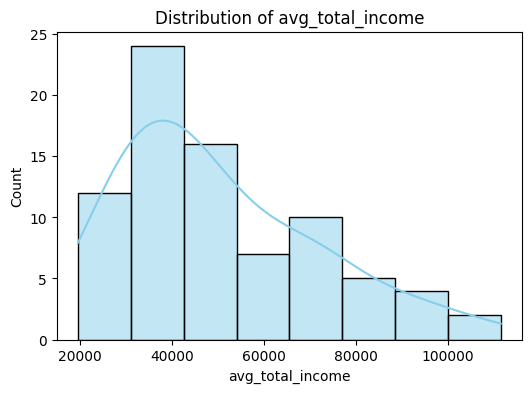

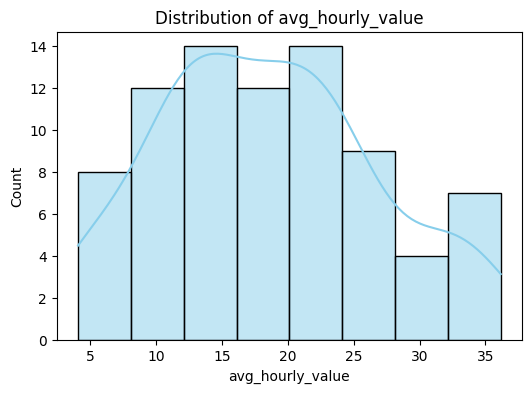

In [ ]:
numerical_columns= merged_data.select_dtypes(include= ['number']).columns
for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(merged_data[col], kde= True, color= 'skyblue')
    plt.title(f'Distribution of {col}')
    plt.show()

**Observation:** From the charts, most of the income-related columns (avg_earnings, avg_wage_salary, avg_total_income) have more values on the lower side and fewer very high values. This means most people earn moderate amounts, while only a small number earn very high incomes.

The year column is evenly spread across 2018-2022, showing that the data covers all years equally.

Most income columns are right-skewed, meaning a few individuals earn very high incomes compared to the majority.

## 2. BIVARIATE ANALYSIS

The goal of this is to study relationships between two variables to identify patterns and associations.

### 2.1 Education Vs Income by Gender.

This helps to compare men and women who earn differently at each education level.

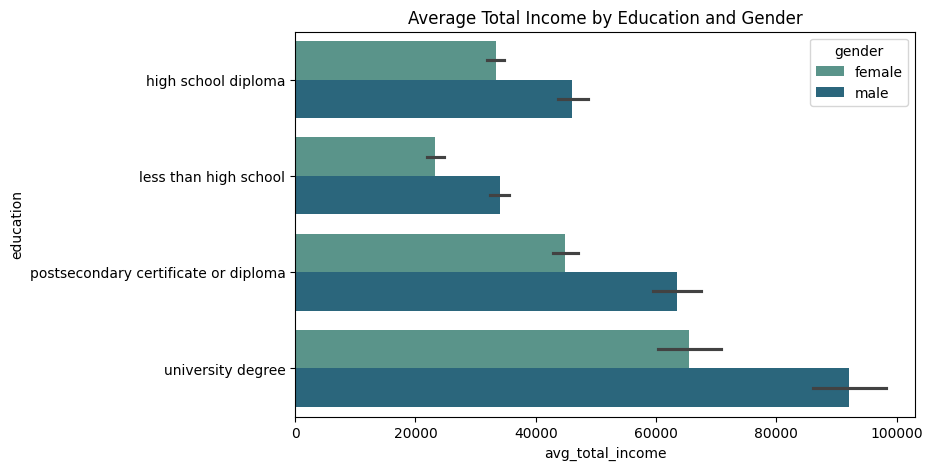

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='avg_total_income', y='education', hue='gender', data=merged_data, palette='crest')
plt.title("Average Total Income by Education and Gender")
plt.show()

### 2.2 Income by Immigrant Status

This shows how the immigration status impacts earnings, which is useful for identifying if there's income disparities for immigrants and non-immigrants.

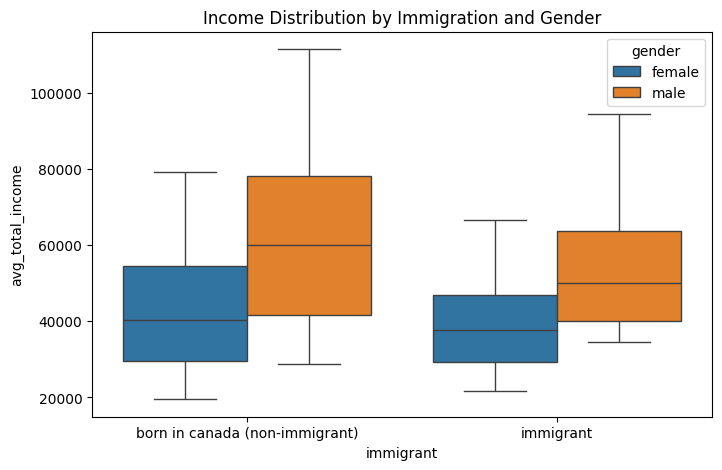

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='immigrant', y='avg_total_income', hue='gender', data=merged_data)
plt.title("Income Distribution by Immigration and Gender")
plt.show()


## 3. MultiVariate Analysis.

The goal of this is to understand how multiple factors interact simultaneously.

This analysis examines how education, gender and immigration status interact to influence income levels.

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remo

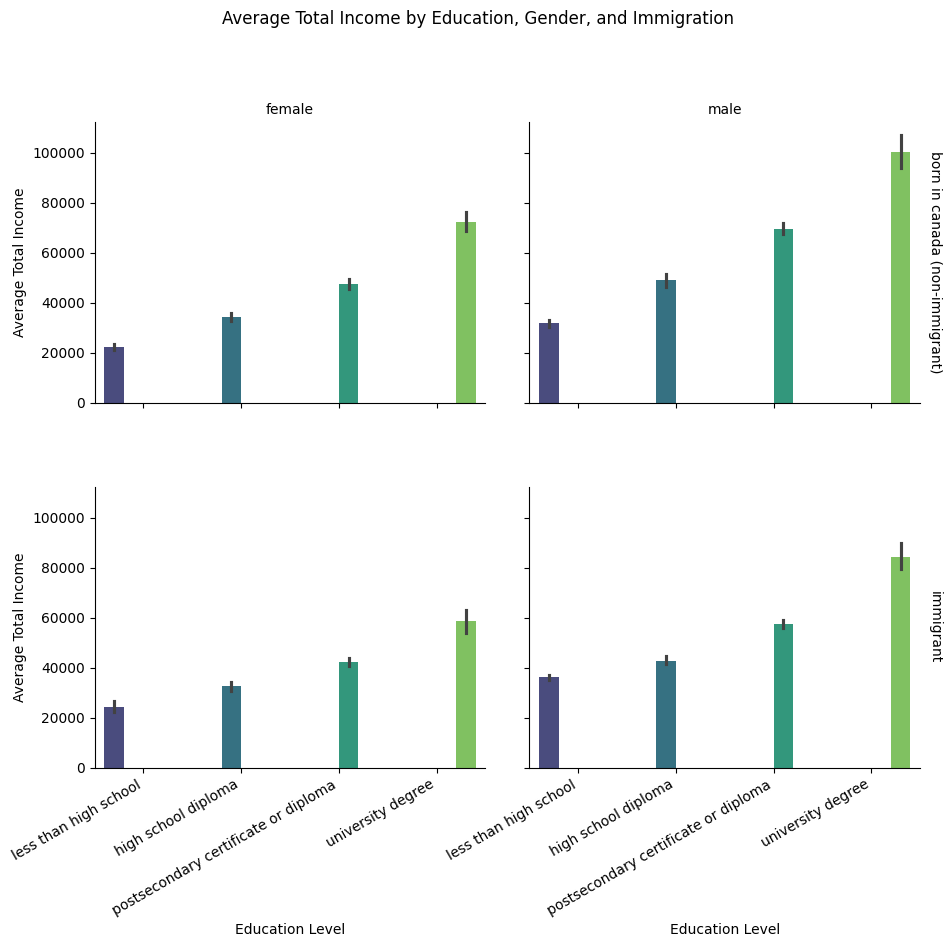

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(
    merged_data,
    col='gender',
    row='immigrant',
    height=4,
    aspect=1.2,
    margin_titles=True
)

g.map_dataframe(
    sns.barplot,
    x='education',
    y='avg_total_income',
    palette='viridis',
    dodge=True,
    order=[
        'less than high school',
        'high school diploma',
        'postsecondary certificate or diploma',
        'university degree'
    ]
)


g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.set_axis_labels("Education Level", "Average Total Income")

for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(30)
        label.set_horizontalalignment('right')

plt.subplots_adjust(top=0.88, hspace=0.3)
g.fig.suptitle("Average Total Income by Education, Gender, and Immigration", y=1.02)

plt.show()


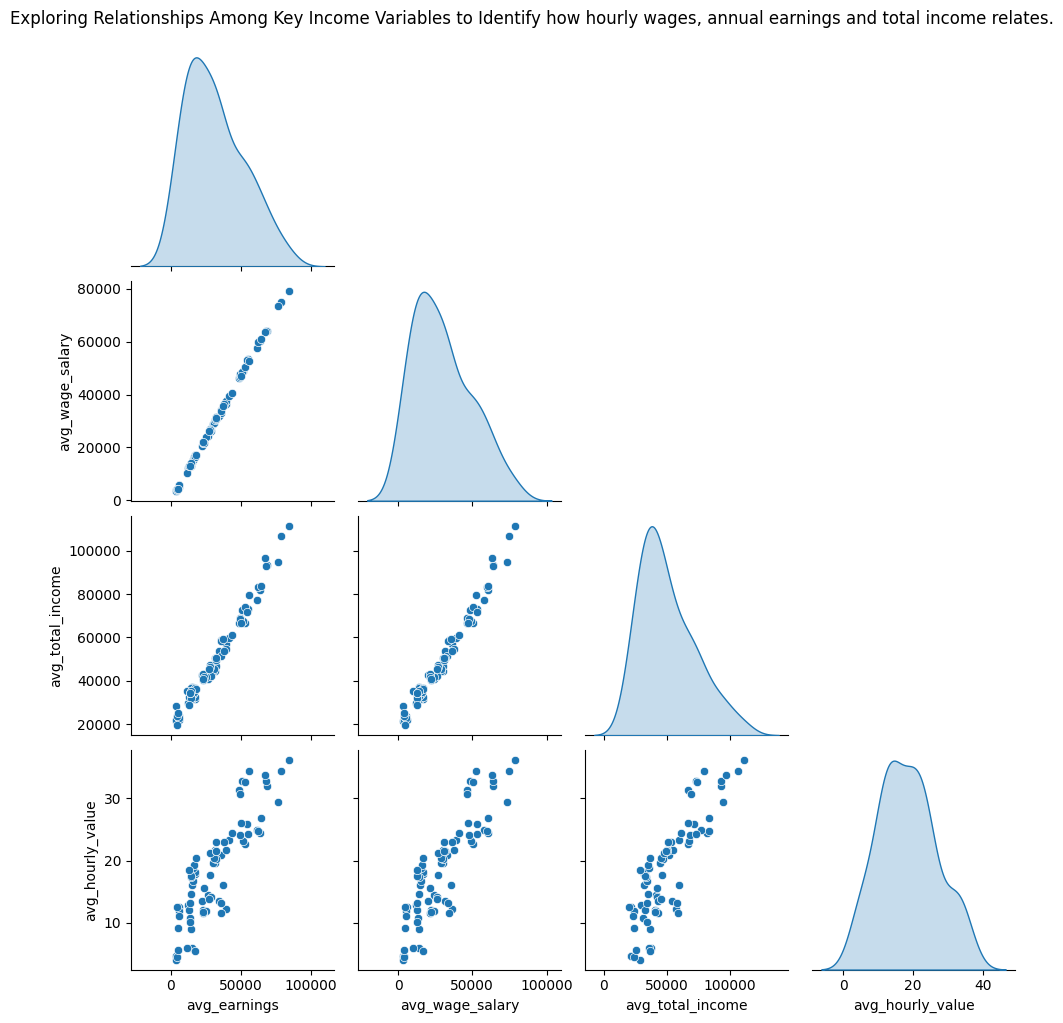

In [ ]:
sns.pairplot(merged_data[['avg_earnings', 'avg_wage_salary', 'avg_total_income', 'avg_hourly_value']], diag_kind='kde', corner=True)
plt.suptitle("Exploring Relationships Among Key Income Variables to Identify how hourly wages, annual earnings and total income relates.", y=1.02)
plt.show()

### 3.1 Correlation Heatmap for the Income variables.

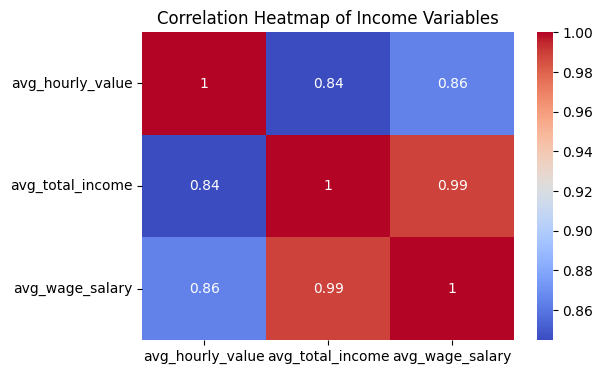

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(merged_data[['avg_hourly_value','avg_total_income','avg_wage_salary']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Income Variables")
plt.show()

**Observation:** This heatmap shows that the income variables are tightly connected, therefore we can trus that they represent consistent income patterns in the dataset.

### 3.2 Correlation Matrix.

This shows how the hourly wages, annual earnning and total incomes are related.

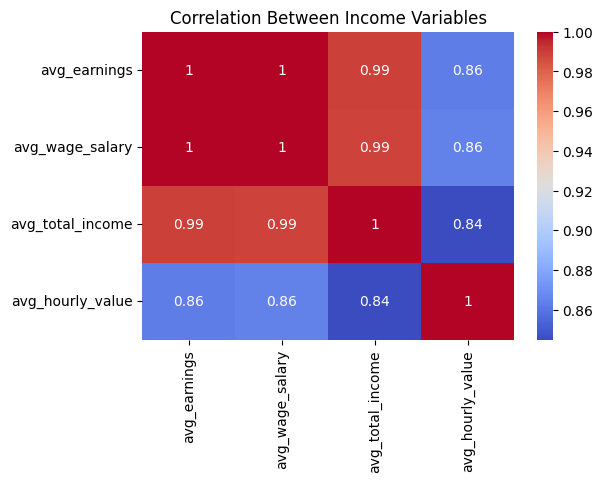

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(merged_data[['avg_earnings','avg_wage_salary','avg_total_income','avg_hourly_value']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Income Variables")
plt.show()

## Outlier check across Education Levels.

/tmp/ipython-input-3031750145.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


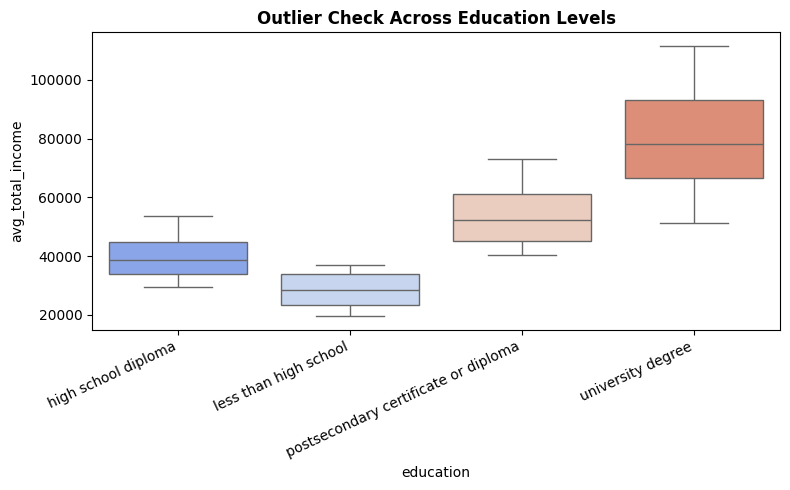

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='education',
    y='avg_total_income',
    data=merged_data,
    palette='coolwarm'
)
plt.title("Outlier Check Across Education Levels", fontsize=12, weight='bold')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()


**Observation:** This chart confirms that higher education leads to higher total income and that the dataset is clean with no distortions in the income distribution.

## Comparison of Average Income and Hourly Wage by Education and Immigration Status.

In [ ]:
merged_data.groupby(['education','immigrant'])[['avg_total_income','avg_hourly_value']].mean().round(2)

avg_total_income  \
education                            immigrant                                          
high school diploma                  born in canada (non-immigrant)          41674.73   
                                     immigrant                               37714.59   
less than high school                born in canada (non-immigrant)          27085.92   
                                     immigrant                               30129.90   
postsecondary certificate or diploma born in canada (non-immigrant)          58541.29   
                                     immigrant                               49863.65   
university degree                    born in canada (non-immigrant)          86294.02   
                                     immigrant                               71368.45   

                                                                     avg_hourly_value  
education                            immigrant                                         
high school diploma                  born in canada (non-immigrant)             20.09  
                                     immigrant                                  13.87  
less than high school                born in canada (non-immigrant)             14.32  
                                     immigrant                                   5.96  
postsecondary certificate or diploma born in canada (non-immigrant)             22.61  
                                     immigrant                                  12.74  
university degree                    born in canada (non-immigrant)             33.10  
                                     immigrant                                  24.70

**Observation:** This confirms that education strongly influences income. However, being an Immigrant leads to lower earnings.